In [52]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score

In [3]:
#loading dataset
credit_card=pd.read_csv(r'C:\Users\RAGU\OneDrive\Desktop\CAG_ML\credit_card_fraud_detection\creditcard.csv')

In [4]:
#first 5 rows
credit_card.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
#last 5 rows
credit_card.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
#dataset information
credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
#checking number of missing values
credit_card.isnull().sum().sort_values(ascending=False)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
#distribution of legit transaction and fraud transaction
credit_card['Class'].value_counts()     #--->it has highly imbalanced dataset

Class
0    284315
1       492
Name: count, dtype: int64

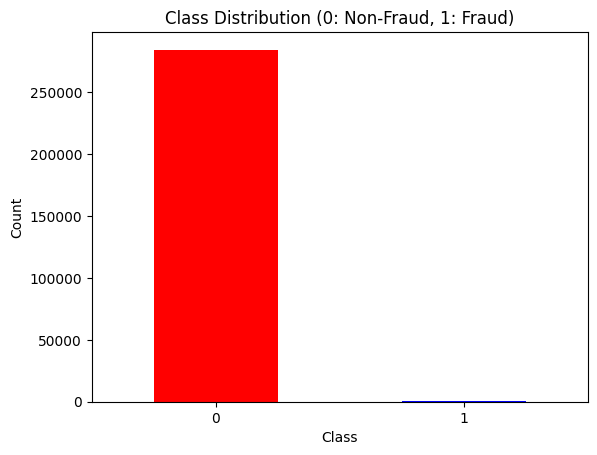

In [20]:
credit_card['Class'].value_counts().plot(kind='bar',color=['red','blue'])
plt.title('Class Distribution (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

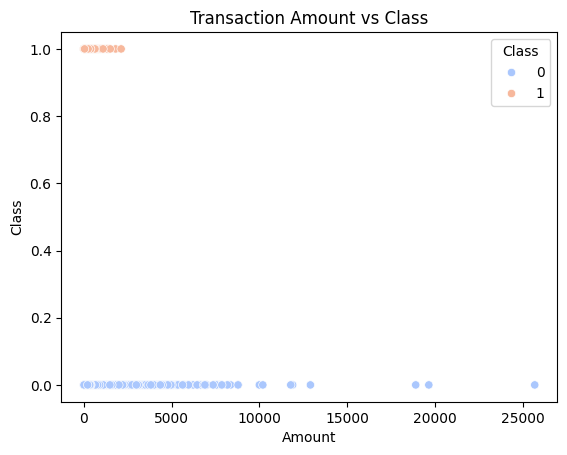

In [27]:
sns.scatterplot(x=credit_card['Amount'], y=credit_card['Class'], hue=credit_card['Class'], palette='coolwarm')
plt.title('Transaction Amount vs Class')
plt.xlabel('Amount')
plt.ylabel('Class')
plt.show()

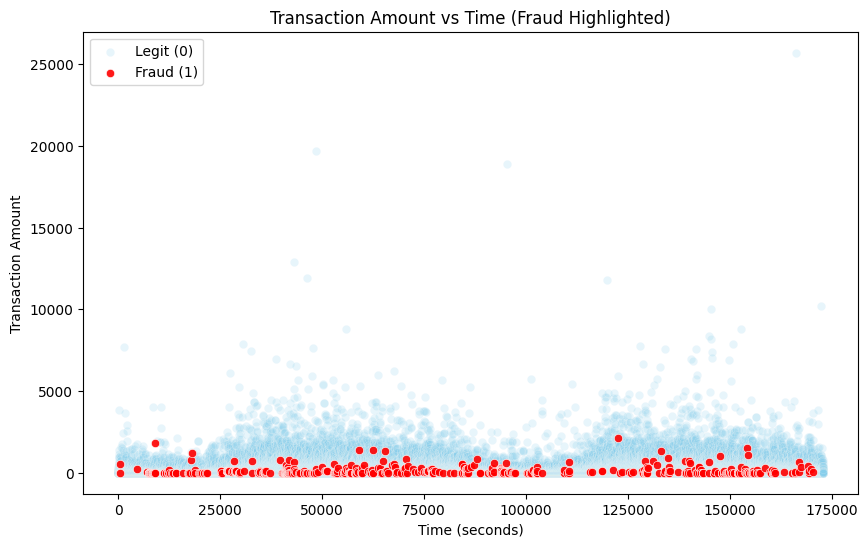

In [33]:
plt.figure(figsize=(10,6))

# Plot legit transactions (lighter)
sns.scatterplot(
    x='Time', y='Amount',
    data=credit_card[credit_card['Class'] == 0],
    color='skyblue', alpha=0.2, label='Legit (0)'
)

# Plot fraud transactions (brighter and on top)
sns.scatterplot(
    x='Time', y='Amount',
    data=credit_card[credit_card['Class'] == 1],
    color='red', alpha=0.9, label='Fraud (1)'
)

plt.title('Transaction Amount vs Time (Fraud Highlighted)')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.legend()
plt.show()


In [36]:
scaler = StandardScaler()

# Scale only 'Amount' and 'Time'
credit_card['Scaled_Amount'] = scaler.fit_transform(credit_card[['Amount']])
credit_card['Scaled_Time'] = scaler.fit_transform(credit_card[['Time']])


In [37]:
#separating data for analysis
legit = credit_card[credit_card.Class==0]
fraud = credit_card[credit_card.Class==1]

print("legit_shape:",legit.shape)
print("fraud_shape:",fraud.shape)

legit_shape: (284315, 33)
fraud_shape: (492, 33)


In [38]:
#statistical measures of the data
legit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Scaled_Time
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0,284315.000000,284315.000000
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0,-0.000234,0.000513
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0,0.999942,0.999915
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0,-0.353229,-1.996583
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0,-0.330640,-0.854612
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0,-0.265271,-0.212745
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0,-0.045177,0.937481
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0,102.362243,1.642058


In [39]:
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Scaled_Time
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0,492.000000,492.000000
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0,0.135382,-0.296223
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0,1.026242,1.007313
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0,-0.353229,-1.988034
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0,-0.349231,-1.128123
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0,-0.316247,-0.405267
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0,0.070128,0.709002
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0,8.146182,1.590592


In [40]:
#compare the values for both transactions
credit_card.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Scaled_Amount,Scaled_Time
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,-0.000234,0.000513
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,0.135382,-0.296223


In [41]:
#dealing unbalanced data with undersampling

#build a sample dataset containing similar distribution of legit transaction and fraud transaction
#legit_shape: (284315, 31)
#fraud_shape: (492, 31)

legit_sample=legit.sample(n=492)

In [42]:
#concatenate legit_sample(492) and fraud(492) as a dataframe
new_df=pd.concat([legit_sample,fraud],axis=0)

In [43]:
new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Scaled_Time
185753,126810.0,0.308615,-0.469102,-1.550750,-2.051320,1.370651,-0.837395,1.780701,-1.095026,-1.192660,...,0.024027,0.133886,-1.412091,-0.412820,-0.051846,-0.132106,164.95,0,0.306255,0.673772
195814,131229.0,-0.141806,0.126412,-0.494090,-0.554668,1.989893,0.499769,1.030752,-0.162739,0.478109,...,0.248508,-1.478438,-0.606293,-0.155188,-0.236529,-0.436140,18.05,0,-0.281064,0.766827
65301,51517.0,0.525229,-0.512101,0.184166,2.521504,-0.059014,0.761807,0.234106,0.250495,-0.923922,...,-0.311042,-0.275715,0.333134,0.160754,-0.045010,0.048288,285.25,0,0.787225,-0.911742
185861,126852.0,-4.090292,-1.139905,-1.106490,-0.283219,-0.363649,1.888645,1.169578,0.353256,0.967996,...,0.978648,-1.615160,-0.879634,-0.796080,-0.998909,0.601208,303.49,0,0.860150,0.674657
177064,123022.0,1.576535,-0.572235,-2.518979,1.199940,0.921787,-0.292213,1.055027,-0.373722,-0.268534,...,-0.452757,-1.050241,0.621756,-0.366254,-0.079117,-0.041994,268.05,0,0.718458,0.594005


In [44]:
new_df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Scaled_Time
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1,1.206024,1.565196
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1,-0.350191,1.569513
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1,-0.041818,1.569597
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1,0.626302,1.582548
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1,-0.183191,1.590592


In [45]:
new_df['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [46]:
new_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Scaled_Amount,Scaled_Time
Class,,,,,,,,,,,,,,,,,,,,,
0,93298.471545,0.023870,0.104687,0.007997,-0.007983,-0.004580,0.042697,0.044833,0.031844,0.081886,...,-0.024970,0.014497,-0.007693,-0.015010,0.012396,-0.010874,0.003035,89.933476,0.006332,-0.031911
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,0.135382,-0.296223


In [47]:
#splitting data as input and target

X=new_df.drop(columns=['Class','Time','Amount'],axis=1)
Y=new_df['Class']

In [48]:
X.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Scaled_Amount',
       'Scaled_Time'],
      dtype='object')

In [49]:
#train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,stratify=Y,random_state=5)

In [51]:
#model training
models=[]
models.append(("Logistic_regression",LogisticRegression(class_weight='balanced',max_iter=1000)))
models.append(("DecisionTreeClassifier",DecisionTreeClassifier()))
models.append(("Randomforest_classifier",RandomForestClassifier()))
models.append(("KNN_Classifier",KNeighborsClassifier(n_neighbors=5)))

print(models)


[('Logistic_regression', LogisticRegression(class_weight='balanced', max_iter=1000)), ('DecisionTreeClassifier', DecisionTreeClassifier()), ('Randomforest_classifier', RandomForestClassifier()), ('KNN_Classifier', KNeighborsClassifier())]


In [55]:
# Train and evaluate models
for name, model in models:
    print("="*60)
    print(f"Model: {name}")
    print("="*60)
    
    model.fit(X_train, Y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training set evaluation
    print("\n🔹 TRAINING PERFORMANCE 🔹")
    print("Accuracy:", accuracy_score(Y_train, y_train_pred))
    print("Precision:", precision_score(Y_train, y_train_pred))
    print("Recall:", recall_score(Y_train, y_train_pred))
    print("F1 Score:", f1_score(Y_train, y_train_pred))
    print("Confusion Matrix:\n", confusion_matrix(Y_train, y_train_pred))
    
    # Testing set evaluation
    print("\n🔹 TESTING PERFORMANCE 🔹")
    print("Accuracy:", accuracy_score(Y_test, y_test_pred))
    print("Precision:", precision_score(Y_test, y_test_pred))
    print("Recall:", recall_score(Y_test, y_test_pred))
    print("F1 Score:", f1_score(Y_test, y_test_pred))
    print("Confusion Matrix:\n", confusion_matrix(Y_test, y_test_pred))
    print("\nSample predictions:\n", 
          pd.DataFrame({"Actual": Y_test.values, "Predicted": y_test_pred}).head())
    print("\n\n")

Model: Logistic_regression

🔹 TRAINING PERFORMANCE 🔹
Accuracy: 0.9498644986449865
Precision: 0.9853801169590644
Recall: 0.9132791327913279
F1 Score: 0.9479606188466948
Confusion Matrix:
 [[364   5]
 [ 32 337]]

🔹 TESTING PERFORMANCE 🔹
Accuracy: 0.9552845528455285
Precision: 1.0
Recall: 0.9105691056910569
F1 Score: 0.9531914893617022
Confusion Matrix:
 [[123   0]
 [ 11 112]]

Sample predictions:
    Actual  Predicted
0       1          1
1       1          1
2       0          0
3       0          0
4       0          0



Model: DecisionTreeClassifier

🔹 TRAINING PERFORMANCE 🔹
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[369   0]
 [  0 369]]

🔹 TESTING PERFORMANCE 🔹
Accuracy: 0.9024390243902439
Precision: 0.9024390243902439
Recall: 0.9024390243902439
F1 Score: 0.9024390243902439
Confusion Matrix:
 [[111  12]
 [ 12 111]]

Sample predictions:
    Actual  Predicted
0       1          1
1       1          1
2       0          0
3       0          0
4       0 